# 도전학기 '빅데이터와 인공지능을 활용한 시스템 강건설계' AI 챌린지!

#### - AI 챌린지 목표 
: 실습내용을 바탕으로 직접 인공지능(2D CNN) 모델을 학습시키는 코드를 작성하는 능력 평가


#### - 가이드에 따라 총 3단계를 수행하며, 각 단계의 결과값(Result 폴더 + 해당 코드 파일)을 1개 압축파일(.zip)로 제출
- 과제 수행을 위해 최소한 가이드가 있으나 가이드에 따르지 않고 다른 방법으로 코드 작성해도 결과만 맞으면 무관
- 과제 내용: 베어링 진동 데이터 spectrogram 활용 2D CNN 고장진단 모델 구축 및 평가

#### - 데이터 출처
- 베어링 마모 상태에 따라 수집된 센서데이터

#### - 데이터 구성
- 정상 베어링 데이터 200개, 케이지 고장 베어링 데이터 200개 (총 400개)
- X/Y축 가속도 값 20000Hz로 수집, 데이터 1개당 수집 시간 3초 -> 60000 rows, 2 columns

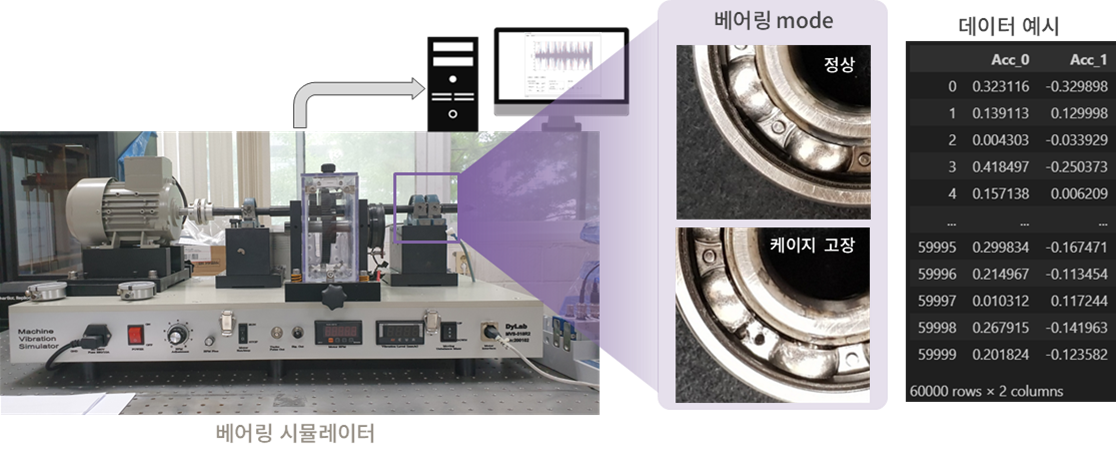

## 라이브러리 import 

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import tensorflow as tf
from tensorflow import keras

## 데이터 살펴보기

In [ ]:
data1 = pd.read_csv('./BearingData/2000RPM_Normal_1')
data2 = pd.read_csv('./BearingData/2000RPM_Cage_1')

In [ ]:
time = np.arange(0, 3, 1/20000)

plt.figure(1, (20, 8))
plt.plot(time, data2.iloc[:,0], c='r', alpha=0.7, lw=0.2, label = 'Acc_0')
plt.plot(time, data2.iloc[:,1], c='b', alpha=0.7, lw=0.2, label = 'Acc_1')
plt.legend()
plt.xlabel('time (sec)'); plt.ylabel('Acc. (g)')
plt.show()

In [ ]:
# STFT test
f,t,Sxx = signal.spectrogram(data1.iloc[:,0], fs = 20000, nperseg = 398, noverlap = 99)

plt.figure(figsize=(9,6))
plt.pcolormesh(t, f, Sxx, cmap = 'hot', alpha = 0.7)

plt.xlabel('Time(s)', fontsize=12)
plt.ylabel('Frequency(Hz)', fontsize=12)
plt.title('STFT Result', fontsize=20)
plt.colorbar()
plt.show()

# [1단계] 센서 데이터 불러오기 + Spectrogram 변환
> #### 전체 데이터 불러오기 및 STFT 변환
> #### 데이터 앞쪽 200개 정상, 뒤쪽 200개 고장
> #### 2D CNN 모델 입력에 적합한 shape로 가공 -> (400, 200, 200, 1)

## 필수!
* 데이터의 'Acc_1'만 사용
* 추출한 데이터(numpy array) 변수명: TotalData_STFT
* 추출한 데이터(numpy array) shape: (400,200,200,1) -> spectrogram 함수 사용 시 nperseg = 398, noverlap = 99 입력

In [ ]:
# 데이터 갯수 정의


In [ ]:
# 전체 가속도 데이터 만들기


In [ ]:
# 전체 데이터 spectrogram 생성


In [ ]:
# Data Reshape for CNN


### 1단계 결과물 제출용 파일로 저장(수강생 번호 외 코드 수정 X)

In [ ]:
StudentNo = 0   # 수강생 번호 입력

Path = './Result/ST%d_AC1.csv'%StudentNo
AC1 = np.concatenate([TotalData_STFT[100, 0, :, :], TotalData_STFT[300, 0, :, :]])
pd.DataFrame(AC1).to_csv(Path, header=None, index=None)

# [2단계] spectrogram 데이터 train/valid 분할 및 레이블 생성
> #### 정상/고장 각 200개 중 앞쪽 150개를 train, 뒤쪽 50개를 valid로 분할
> #### 학습 데이터 앞쪽 150개 정상, 뒤쪽 150개 고장
> #### 검증 데이터 앞쪽 50개 정상, 뒤쪽 50개 고장

## 필수!
* 학습 데이터 변수명(np array): TrainData
* 검증 데이터 변수명(np array): ValidData

- 정상 학습 데이터 범위: 2000RPM_Normal_1   ~ 2000RPM_Normal_150
- 정상 검증 데이터 범위: 2000RPM_Normal_151 ~ 2000RPM_Normal_200
- 고장 학습 데이터 범위: 2000RPM_Abnormal_1   ~ 2000RPM_Abnormal_150
- 고장 검증 데이터 범위: 2000RPM_Abnormal_151 ~ 2000RPM_Abnormal_200

In [ ]:
# 정상/고장 분할


In [ ]:
# 정상 및 고장 별 학습/검증 분할


In [ ]:
# 학습 및 검증 데이터 합치기


In [ ]:
# 학습 및 검증 레이블 생성


### 2단계 결과물 제출용 파일로 저장(수강생 번호 외 코드 수정 X)

In [ ]:
StudentNo = 0   # 수강생 번호 입력

Path = './Result/ST%d_AC2.csv'%StudentNo
AC2 = np.concatenate([TrainData[50, 0, :, :], TrainData[250, 0, :, :], ValidData[25, 0, :, :], ValidData[75, 0, :, :]], axis = 0)
pd.DataFrame(AC2).to_csv(Path, header=None, index=None)

# [3단계] 2D CNN 모델 설계 및 학습
> #### 아래와 같은 모델 구조가 되도록 2D CNN 분류 모델 설계 및 학습
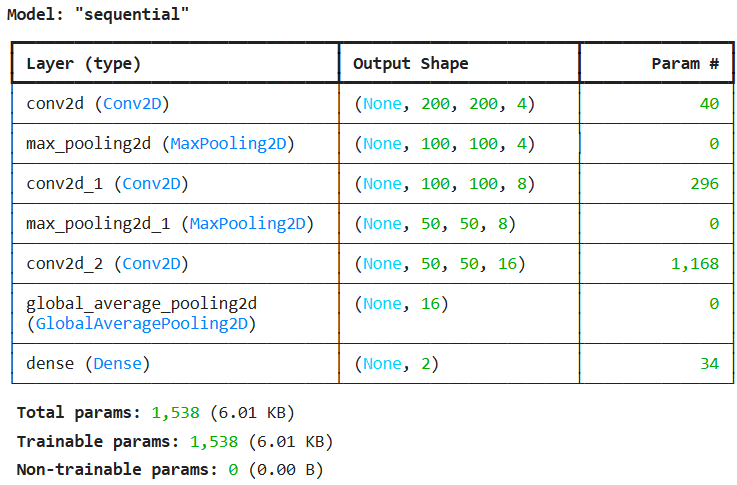

> #### 학습 및 검증 데이터를 학습 완료된 모델에 입력하여 Loss, Accuracy 계산

## 필수!
* 2d conv. layer 파라미터: kernel size=3x3, strides=1x1, padding=same, activation=relu
* 2d max pooling 파라미터: pool size=2x2, strides=2x2
* dense layer(마지막 분류 레이어) 파라미터: activation=softmax
* loss function: categorical cross entropy
* optimizer: Adam
* learning rate 0.0002, Epoch 200

* 학습 데이터에 대한 Loss, Accuracy 변수명: Train_Loss, Train_Acc
* 검증 데이터에 대한 Loss, Accuracy 변수명: Valid_Loss, Valid_Acc
(단위는 모두 모델 출력 값 그대로 사용, %로 출력 X)

## CNN(Convolution Neural Network) hyperparameter 설정

In [ ]:
# 변경 X
learningRate  = 0.0002
Epoch         = 200

## Keras 기반 CNN 구조(Architecture) 설계

In [ ]:
def CNN(input_data):
    #### 변경 X
    random_seed = 777
    keras.backend.clear_session()
    tf.keras.utils.set_random_seed(random_seed)
    #### 변경 X



    return model

In [ ]:
# 모델 만들기
CNN_model = CNN(TrainData)

# 모델 구조, 파라미터 개수 확인
CNN_model.summary()

In [ ]:
# 모델 학습


In [ ]:
# 모델에 학습 및 검증 데이터/레이블 입력 및 loss, accuracy 확인


### 3단계 결과물 제출용 파일로 저장(수강생 번호 외 코드 수정 X)

In [ ]:
StudentNo = 0   # 수강생 번호 입력

Path = './Result/ST%d_AC3.csv'%StudentNo
AC3 = [round(Train_Loss, 3), round(Train_Acc, 3), round(Valid_Loss, 3), round(Valid_Acc, 3)]
pd.DataFrame(AC3).to_csv(Path, header=None, index=None)

# ● 결과가 저장된 폴더(Result)와 작성 완료된 본 코드 파일을 하나의 zip파일로 제출
> ## 압축파일 이름 ST(수강생번호)_AC (예시: 'ST00_AC', 'ST0_AC')
압축파일 더블클릭시 Result 폴더, AIChallenge_ST-(수강생번호) 나타나도록 파일 구성